In [1]:
# ==============================================================================
# CELL 1: SETUP, IMPORTS, AND ENHANCED CONFIGURATION
# ==============================================================================
import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time 

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import LambdaLR 

import timm
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize, LabelEncoder
from tqdm import tqdm # Used for feature extraction in Cell 4

# --- Configuration (ViT-Base) ---
MAE_ENCODER_NAME = 'vit_base_patch16_224' 
IMG_SIZE = 224
PATCH_SIZE = 16 
MASK_RATIO = 0.75 
BATCH_SIZE = 64
PRE_TRAIN_EPOCHS = 100 # Long run for feature learning (MAE)
PROBE_EPOCHS = 20    
FINETUNE_EPOCHS = 30 #  INCREASED TO 30 EPOCHS (Strategy 1)
LEARNING_RATE = 1e-4 
PROBE_LR = 1e-3      
# REDUCED LR for stable fine-tuning (Strategy 1)
FINETUNE_LR = 5e-6   
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 10 
SEED = 42
MAE_ENCODER_CHECKPOINT = 'mae_vit_encoder_best.pth'
PROBE_CHECKPOINT = 'linear_probe_best.pth'
FINETUNE_CHECKPOINT = 'full_finetune_best.pth'
WORKING_DIR = "mae_working_data" 

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Set random seeds for reproducibility
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
set_seed(SEED)

# Dummy check for a necessary function (will be fully defined in Cell 4)
def evaluate_model(*args, **kwargs):
    print("Warning: evaluate_model is a placeholder and needs full definition in Cell 4.")
    
print("All configurations loaded. Fine-tuning is set for 30 epochs with a gentler LR.")

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Using device: cuda
All configurations loaded. Fine-tuning is set for 30 epochs with a gentler LR.


In [2]:
# ==============================================================================
# CELL 2: DATA PREPARATION (DOWNLOAD, STRUCTURE TRAVERSAL, AND SPLIT)
# ==============================================================================
# --- 1. Dataset Download (Using your specified source) ---
print("Starting dataset download via kagglehub...")
DOWNLOAD_PATH = kagglehub.dataset_download("mdriyadhossain/ai-medleafx")
ORIGINAL_DATASET_ROOT = str(DOWNLOAD_PATH)
RESIZED_IMAGE_BASE_PATH = os.path.join(ORIGINAL_DATASET_ROOT, 'Resized Image')

print(f"Dataset downloaded to: {ORIGINAL_DATASET_ROOT}")

# 2. Check and Cleanup working directory
if os.path.exists(WORKING_DIR):
    print(f"Clearing previous working directory: {WORKING_DIR}")
    shutil.rmtree(WORKING_DIR)

# 3. Create the main working directory structure
os.makedirs(WORKING_DIR, exist_ok=True)
os.makedirs(os.path.join(WORKING_DIR, 'train'), exist_ok=True)
os.makedirs(os.path.join(WORKING_DIR, 'val'), exist_ok=True)
os.makedirs(os.path.join(WORKING_DIR, 'test'), exist_ok=True)


# 4. Traversal Logic to Get all Image Paths and Labels
all_image_paths = []
all_labels = []
print("\nExploring dataset structure and gathering all image paths:")

try:
    for plant_type_dir in os.listdir(RESIZED_IMAGE_BASE_PATH):
        plant_type_path = os.path.join(RESIZED_IMAGE_BASE_PATH, plant_type_dir)
        if not os.path.isdir(plant_type_path): continue

        for status_dir in os.listdir(plant_type_path):
            class_name = f"{plant_type_dir}_{status_dir}" 
            class_path = os.path.join(plant_type_path, status_dir)
            if not os.path.isdir(class_path): continue
            
            image_files = [os.path.join(class_path, f) for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            all_image_paths.extend(image_files)
            all_labels.extend([class_name] * len(image_files))

except FileNotFoundError:
    print(f"CRITICAL ERROR: The directory '{RESIZED_IMAGE_BASE_PATH}' was not found.")
    raise

all_class_names = sorted(list(set(all_labels)))
NUM_CLASSES = len(all_class_names)
print(f"\nTotal number of unique classes found: {NUM_CLASSES}")
print(f"Total number of images found: {len(all_image_paths)}")


# 5. Perform the 36% / 4% / 60% split
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.60, stratify=all_labels, random_state=SEED
)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels, test_size=0.10, stratify=train_val_labels, random_state=SEED
) 

print(f"\nTrain (36%): {len(train_paths)}")
print(f"Val (4%): {len(val_paths)}")
print(f"Test (60%): {len(test_paths)}")


# 6. Copy files to the respective working directories
def copy_files(paths, labels, target_subdir):
    target_dir = os.path.join(WORKING_DIR, target_subdir)
    path_label_map = {p: l for p, l in zip(all_image_paths, all_labels) if p in paths}
    
    for path in paths:
        class_name = path_label_map.get(path)
        if class_name:
            os.makedirs(os.path.join(target_dir, class_name), exist_ok=True)
            shutil.copy(path, os.path.join(target_dir, class_name, os.path.basename(path)))

copy_files(train_paths, train_labels, 'train')
copy_files(val_paths, val_labels, 'val')
copy_files(test_paths, test_labels, 'test')
print("File copying complete.")


# 7. MAE Pre-training DataLoaders
mae_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

mae_dataset = datasets.ImageFolder(os.path.join(WORKING_DIR, 'train'), transform=mae_transform)
pretrain_loader = DataLoader(mae_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

print(f"MAE Pre-training DataLoader created with {len(pretrain_loader)} batches.")

Starting dataset download via kagglehub...
Dataset downloaded to: /kaggle/input/ai-medleafx

Exploring dataset structure and gathering all image paths:

Total number of unique classes found: 13
Total number of images found: 10858

Train (36%): 3908
Val (4%): 435
Test (60%): 6515
File copying complete.
MAE Pre-training DataLoader created with 62 batches.


In [3]:
# ==============================================================================
# CELL 3: CUSTOM MAE MODEL DEFINITION AND PRE-TRAINING (100 EPOCHS)
# ==============================================================================

# --- 1. Custom MAE Wrapper Class ---
class MaskedAutoencoder(nn.Module):
    def __init__(self, encoder_name=MAE_ENCODER_NAME, mask_ratio=MASK_RATIO, img_size=IMG_SIZE, patch_size=PATCH_SIZE):
        super().__init__()
        
        self.encoder = timm.create_model(
            encoder_name,
            pretrained=False,
            img_size=img_size,
            patch_size=patch_size,
            num_classes=0, 
            drop_path_rate=0.0
        )
        
        embed_dim = self.encoder.embed_dim
        decoder_embed_dim = embed_dim
        
        self.decoder_embed = nn.Linear(embed_dim, decoder_embed_dim, bias=True)
        self.decoder_pred = nn.Linear(decoder_embed_dim, patch_size**2 * 3, bias=True) 

        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.mask_ratio = mask_ratio
        self.initialize_weights()

    def initialize_weights(self):
        torch.nn.init.normal_(self.mask_token, std=.02)

    def patchify(self, imgs):
        """imgs: (N, 3, H, W) -> (N, L, patch_size**2 * 3)"""
        p = self.encoder.patch_embed.patch_size[0]
        h = w = imgs.shape[2] // p
        x = imgs.reshape(shape=(imgs.shape[0], 3, h, p, w, p))
        x = torch.einsum('nchpwq->nhwpqc', x)
        return x.reshape(shape=(imgs.shape[0], h * w, p**2 * 3))

    def random_masking(self, x, mask_ratio):
        """Perform MAE style random masking. x: [N, L, D]"""
        N, L, D = x.shape
        len_keep = int(L * (1 - mask_ratio))
        
        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, dim=1, index=ids_keep.unsqueeze(-1).repeat(1, 1, D))

        mask = torch.ones([N, L], device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_masked, mask, ids_restore

    def forward_encoder(self, x):
        x = self.encoder.patch_embed(x)
        x = x + self.encoder.pos_embed[:, 1:, :] 
        x, mask, ids_restore = self.random_masking(x, self.mask_ratio)

        cls_token = self.encoder.cls_token + self.encoder.pos_embed[:, :1, :]
        x = torch.cat((cls_token.expand(x.shape[0], -1, -1), x), dim=1)
        
        for blk in self.encoder.blocks:
            x = blk(x)
            
        x = self.encoder.norm(x)
        return x[:, 1:, :], mask, ids_restore

    def forward_decoder(self, x, ids_restore):
        x = self.decoder_embed(x)
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] - x.shape[1], 1)
        x_ = torch.cat([x, mask_tokens], dim=1)
        x = torch.gather(x_, dim=1, index=ids_restore.unsqueeze(-1).repeat(1, 1, x_.shape[2]))
        x = self.decoder_pred(x)
        return x

    def forward(self, imgs):
        latent, mask, ids_restore = self.forward_encoder(imgs)
        pred = self.forward_decoder(latent, ids_restore)
        target = self.patchify(imgs)
        
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        
        return loss, pred, mask

# --- 2. MAE Training Setup ---
mae_model = MaskedAutoencoder().to(DEVICE)
SCALED_LR = LEARNING_RATE * BATCH_SIZE / 256

mae_optimizer = optim.AdamW(
    mae_model.parameters(), lr=SCALED_LR, betas=(0.9, 0.95), weight_decay=WEIGHT_DECAY
)

def get_lr_scheduler(optimizer, warmup_epochs, max_epochs, steps_per_epoch, min_lr=1e-6):
    def lr_lambda(step):
        total_steps = max_epochs * steps_per_epoch
        warmup_steps = warmup_epochs * steps_per_epoch
        if step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        cosine_decay = 0.5 * (1. + np.cos(np.pi * progress))
        min_ratio = min_lr / SCALED_LR
        return max(min_ratio, cosine_decay)
    return LambdaLR(optimizer, lr_lambda)

mae_scheduler = get_lr_scheduler(mae_optimizer, WARMUP_EPOCHS, PRE_TRAIN_EPOCHS, len(pretrain_loader))
print(f"MAE Model and Scheduler configured. Scaled LR: {SCALED_LR:.6f}")


# --- 3. MAE Pre-training Loop (100 Epochs) ---
def train_mae(model, loader, optimizer, scheduler, device, epochs, checkpoint_name):
    model.train()
    best_loss = float('inf')
    print("Starting MAE Pre-training...")
    
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        running_loss = 0.0
        
        for images, _ in loader:
            images = images.to(device)
            loss, _, _ = model(images) 
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(loader)
        epoch_time = time.time() - start_time
        
        print(f"\n--- Epoch {epoch} Summary ---")
        print(f"Average Training Loss: {epoch_loss:.4f} | Time Taken: {epoch_time:.2f} seconds")

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(model.encoder.state_dict(), checkpoint_name)
            print(f">>> Saved best MAE ViT Encoder weights to {checkpoint_name}.")

# Execute Pre-training (Run this for 100 epochs, will take time)
train_mae(mae_model, pretrain_loader, mae_optimizer, mae_scheduler, DEVICE, PRE_TRAIN_EPOCHS, MAE_ENCODER_CHECKPOINT) 
print(f"\nMAE Pre-training complete. ViT Encoder saved to '{MAE_ENCODER_CHECKPOINT}'")

MAE Model and Scheduler configured. Scaled LR: 0.000025
Starting MAE Pre-training...

--- Epoch 1 Summary ---
Average Training Loss: 0.4457 | Time Taken: 29.82 seconds
>>> Saved best MAE ViT Encoder weights to mae_vit_encoder_best.pth.

--- Epoch 2 Summary ---
Average Training Loss: 0.4444 | Time Taken: 30.15 seconds
>>> Saved best MAE ViT Encoder weights to mae_vit_encoder_best.pth.

--- Epoch 3 Summary ---
Average Training Loss: 0.4386 | Time Taken: 32.29 seconds
>>> Saved best MAE ViT Encoder weights to mae_vit_encoder_best.pth.

--- Epoch 4 Summary ---
Average Training Loss: 0.4295 | Time Taken: 35.04 seconds
>>> Saved best MAE ViT Encoder weights to mae_vit_encoder_best.pth.

--- Epoch 5 Summary ---
Average Training Loss: 0.4174 | Time Taken: 35.18 seconds
>>> Saved best MAE ViT Encoder weights to mae_vit_encoder_best.pth.

--- Epoch 6 Summary ---
Average Training Loss: 0.4025 | Time Taken: 34.15 seconds
>>> Saved best MAE ViT Encoder weights to mae_vit_encoder_best.pth.

--- Epoc

In [4]:
# ==============================================================================
# CELL 4: DOWNSTREAM SETUP, ENHANCED TRANSFORMS, AND MODEL DEFINITION
# ==============================================================================
#  ENHANCED TRANSFORMS for supervised learning (Strategy 2)
supervised_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    # Data Augmentation:
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), 
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
    # End Augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 1. Update DataLoaders for Supervised Training
train_dataset = datasets.ImageFolder(os.path.join(WORKING_DIR, 'train'), transform=supervised_transforms)
val_dataset = datasets.ImageFolder(os.path.join(WORKING_DIR, 'val'), transform=supervised_transforms)
test_dataset = datasets.ImageFolder(os.path.join(WORKING_DIR, 'test'), transform=supervised_transforms)
    
LINEAR_PROBE_CLASSES = train_dataset.classes
NUM_CLASSES = len(LINEAR_PROBE_CLASSES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print("Supervised DataLoaders created with data augmentation.")


# 2. Define the Probe Model Class (Used for both Probe and Fine-Tuning)
class LinearProbeViT(nn.Module):
    def __init__(self, encoder_name, num_classes, checkpoint_path, freeze=True):
        super().__init__()
        
        self.encoder = timm.create_model(
            encoder_name,
            pretrained=False,
            num_classes=0 # Strip original head
        )
        
        state_dict = torch.load(checkpoint_path, map_location='cpu')
        
        keys_to_delete = ['head.weight', 'head.bias']
        for key in keys_to_delete:
            if key in state_dict:
                del state_dict[key]
        
        msg = self.encoder.load_state_dict(state_dict, strict=True)
        print(f"Loaded MAE ViT Encoder weights with message: {msg}")
        
        # Freeze or Unfreeze based on the argument
        if freeze:
            for param in self.encoder.parameters():
                param.requires_grad = False
            print("Encoder frozen.")
        else:
            for param in self.encoder.parameters():
                param.requires_grad = True
            print("Encoder UNFROZEN for fine-tuning.")
            
        feature_dim = self.encoder.embed_dim 
        self.head = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Linear(feature_dim, num_classes)
        )
        
    def forward(self, x):
        features = self.encoder.forward_features(x)
        cls_token = features[:, 0]
        return self.head(cls_token)


# 3. Define Re-usable Evaluation Function
def evaluate_model(model, test_loader, classes, report_name):
    print(f"\n--- Evaluating {report_name} Model on the 60% TEST SET ---")
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images).cpu()
            
            probabilities = torch.nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_preds.extend(predicted.numpy())
            all_probs.extend(probabilities.numpy())

    report = classification_report(all_labels, all_preds, target_names=classes, digits=4)
    print(f"\nClassification Report ({report_name}):\n", report)

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    # Ensure correct integer labels are used for binarization
    integer_labels = list(range(len(classes)))
    binarized_labels = label_binarize(all_labels, classes=integer_labels)
    
    if binarized_labels.shape[1] > 1:
        macro_roc_auc = roc_auc_score(binarized_labels, all_probs, average="macro")
        print(f"\nMacro-Averaged ROC-AUC ({report_name}): {macro_roc_auc:.4f}")
        
    cm = confusion_matrix(all_labels, all_preds, labels=integer_labels)
    cm_df = pd.DataFrame(cm, index=classes, columns=classes)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_df, annot=True, fmt='g', cmap='Blues')
    plt.title(f'Confusion Matrix ({report_name})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'{report_name.lower().replace(" ", "_")}_confusion_matrix.png')
    plt.close()
    
    return all_probs, all_labels

Supervised DataLoaders created with data augmentation.


In [5]:
# ==============================================================================
# CELL 5: LINEAR PROBE TRAINING AND BASELINE EVALUATION (20 EPOCHS)
# ==============================================================================
# 1. Instantiate Frozen Model
linear_probe_model = LinearProbeViT(
    encoder_name=MAE_ENCODER_NAME, 
    num_classes=NUM_CLASSES, 
    checkpoint_path=MAE_ENCODER_CHECKPOINT,
    freeze=True # Encoder is FROZEN
).to(DEVICE)
print("\nLinear Probe model initialized. Training only the head.")

# 2. Training Configuration
CRITERION = nn.CrossEntropyLoss()
PROBE_OPTIMIZER = optim.AdamW(
    linear_probe_model.head.parameters(), # ONLY the head parameters
    lr=PROBE_LR, 
    weight_decay=0.0
)

# 3. Training Loop
def train_probe_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, checkpoint_name):
    print(f"\nStarting Linear Probe Training for {epochs} epochs...")
    best_val_loss = float('inf')
    
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        train_loss = running_loss / len(train_loader)
        epoch_time = time.time() - start_time
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
        val_loss /= len(val_loader)
        
        print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {epoch_time:.2f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), checkpoint_name)
            print(f">>> Saved best Linear Probe model state to {checkpoint_name}.")
            
    model.load_state_dict(torch.load(checkpoint_name))
    return model

trained_probe = train_probe_model(
    linear_probe_model, train_loader, val_loader, CRITERION, PROBE_OPTIMIZER, DEVICE, PROBE_EPOCHS, PROBE_CHECKPOINT
)

# 4. Evaluation
evaluate_model(trained_probe, test_loader, LINEAR_PROBE_CLASSES, "Linear Probe")

Loaded MAE ViT Encoder weights with message: <All keys matched successfully>
Encoder frozen.

Linear Probe model initialized. Training only the head.

Starting Linear Probe Training for 20 epochs...
Epoch 1/20 | Train Loss: 2.2034 | Val Loss: 2.0043 | Time: 56.15s
>>> Saved best Linear Probe model state to linear_probe_best.pth.
Epoch 2/20 | Train Loss: 1.9721 | Val Loss: 1.9419 | Time: 53.54s
>>> Saved best Linear Probe model state to linear_probe_best.pth.
Epoch 3/20 | Train Loss: 1.9028 | Val Loss: 1.8607 | Time: 53.18s
>>> Saved best Linear Probe model state to linear_probe_best.pth.
Epoch 4/20 | Train Loss: 1.8283 | Val Loss: 1.8137 | Time: 54.05s
>>> Saved best Linear Probe model state to linear_probe_best.pth.
Epoch 5/20 | Train Loss: 1.7980 | Val Loss: 1.7802 | Time: 53.55s
>>> Saved best Linear Probe model state to linear_probe_best.pth.
Epoch 6/20 | Train Loss: 1.7844 | Val Loss: 1.7488 | Time: 53.79s
>>> Saved best Linear Probe model state to linear_probe_best.pth.
Epoch 7/2

(array([[1.82420522e-01, 3.39110531e-02, 1.08294524e-02, ...,
         9.35330627e-06, 4.94302483e-04, 5.36491143e-06],
        [5.54428041e-01, 5.20045534e-02, 3.30010913e-02, ...,
         4.93852422e-04, 1.93490125e-02, 2.96893995e-04],
        [2.84373254e-01, 2.62784511e-02, 3.80243696e-02, ...,
         3.56040448e-02, 1.34727046e-01, 2.40779370e-02],
        ...,
        [7.90625345e-04, 2.90763419e-04, 1.41898748e-02, ...,
         2.72606325e-04, 1.33693442e-02, 6.47453606e-01],
        [1.01702385e-01, 6.02098294e-02, 1.14197813e-01, ...,
         2.07077060e-03, 1.91236287e-01, 8.97205323e-02],
        [2.54284758e-02, 5.77474013e-03, 2.04763319e-02, ...,
         2.11144328e-01, 8.97670165e-02, 3.96965176e-01]], dtype=float32),
 array([ 0,  0,  0, ..., 12, 12, 12]))

In [6]:
# ==============================================================================
# CELL 6: SHALLOW HEAD EVALUATION (MLP, SVM, DT, RF)
# ==============================================================================
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder, label_binarize

# 1. Feature Extraction using the Frozen MAE Encoder
def extract_features(model, loader, device):
    model.eval()
    all_features = []
    all_labels = []
    encoder = model.encoder 

    print("Starting feature extraction...")
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Extracting Features"):
            images = images.to(device)
            features = encoder.forward_features(images)[:, 0].cpu().numpy()
            all_features.append(features)
            all_labels.append(labels.numpy())
            
    return np.vstack(all_features), np.concatenate(all_labels)

# Instantiate the model and load the best saved state from the Linear Probe run (Cell 5)
probe_model_for_extraction = LinearProbeViT(
    encoder_name=MAE_ENCODER_NAME, 
    num_classes=NUM_CLASSES, 
    checkpoint_path=MAE_ENCODER_CHECKPOINT,
    freeze=True 
).to(DEVICE)
probe_model_for_extraction.load_state_dict(torch.load(PROBE_CHECKPOINT))

# Extract features for all splits
X_train, y_train = extract_features(probe_model_for_extraction, train_loader, DEVICE)
X_val, y_val = extract_features(probe_model_for_extraction, val_loader, DEVICE)
X_test, y_test = extract_features(probe_model_for_extraction, test_loader, DEVICE)

X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val])

print(f"Features extracted. Train+Val shape: {X_train_val.shape}, Test shape: {X_test.shape}")


# 2. Train and Evaluate Shallow Models (Scikit-learn)
classifiers = {
    "SVM": SVC(kernel='linear', C=1.0, random_state=SEED, probability=True),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1),
    "MLP (Scikit-learn)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, random_state=SEED)
}

results = {}
INTEGER_LABELS = list(range(NUM_CLASSES)) 
STRING_LABELS = LINEAR_PROBE_CLASSES 

# Helper function for evaluation
def evaluate_ml_model(name, model):
    start_time = time.time()
    
    model.fit(X_train_val, y_train_val)
    y_pred = model.predict(X_test)
    
    roc_auc = 0.0
    if hasattr(model, "predict_proba"):
        try:
            y_proba = model.predict_proba(X_test)
            y_test_binarized = label_binarize(y_test, classes=INTEGER_LABELS)
            roc_auc = roc_auc_score(y_test_binarized, y_proba, average="macro")
        except:
            pass # Keep ROC-AUC 0.0 if calculation fails
    
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    
    results[name] = {
        'Accuracy': f"{accuracy:.4f}",
        'F1-Macro': f"{f1_macro:.4f}",
        'Recall-Macro': f"{recall_macro:.4f}",
        'ROC-AUC-Macro': f"{roc_auc:.4f}",
        'Time (s)': f"{time.time() - start_time:.2f}"
    }

    print(f"\n--- Results for {name} ---")
    print(f"Accuracy: {results[name]['Accuracy']}, F1-Macro: {results[name]['F1-Macro']}, ROC-AUC: {results[name]['ROC-AUC-Macro']}")

# Run all classifiers
for name, model in classifiers.items():
    evaluate_ml_model(name, model)

print("\n--- Summary of Shallow Head Models on Frozen MAE Features ---")
print(pd.DataFrame(results).T)

Loaded MAE ViT Encoder weights with message: <All keys matched successfully>
Encoder frozen.
Starting feature extraction...


Extracting Features: 100%|██████████| 62/62 [00:55<00:00,  1.11it/s]


Starting feature extraction...


Extracting Features: 100%|██████████| 7/7 [00:06<00:00,  1.07it/s]


Starting feature extraction...


Extracting Features: 100%|██████████| 102/102 [01:28<00:00,  1.16it/s]


Features extracted. Train+Val shape: (4343, 768), Test shape: (6515, 768)

--- Results for SVM ---
Accuracy: 0.6258, F1-Macro: 0.6215, ROC-AUC: 0.9480

--- Results for Decision Tree ---
Accuracy: 0.3905, F1-Macro: 0.3917, ROC-AUC: 0.7558

--- Results for Random Forest ---
Accuracy: 0.4999, F1-Macro: 0.4805, ROC-AUC: 0.9115

--- Results for MLP (Scikit-learn) ---
Accuracy: 0.5840, F1-Macro: 0.5860, ROC-AUC: 0.9419

--- Summary of Shallow Head Models on Frozen MAE Features ---
                   Accuracy F1-Macro Recall-Macro ROC-AUC-Macro Time (s)
SVM                  0.6258   0.6215       0.6281        0.9480    26.35
Decision Tree        0.3905   0.3917       0.3934        0.7558     3.45
Random Forest        0.4999   0.4805       0.5014        0.9115     3.19
MLP (Scikit-learn)   0.5840   0.5860       0.5904        0.9419    10.24


In [7]:
# ==============================================================================
# CELL 7: FULL FINE-TUNING AND FINAL EVALUATION (30 EPOCHS)
# (Using gentler LR and Data Augmentation to hit >80%)
# ==============================================================================
# 1. Instantiate Model and Load Best Probe State
full_finetune_model = LinearProbeViT(
    encoder_name=MAE_ENCODER_NAME, 
    num_classes=NUM_CLASSES, 
    checkpoint_path=MAE_ENCODER_CHECKPOINT,
    freeze=False # CRITICAL: UNFREEZE the encoder
).to(DEVICE)

print(f"Loading best trained head from {PROBE_CHECKPOINT}...")
full_finetune_model.load_state_dict(torch.load(PROBE_CHECKPOINT), strict=True)
print("Model initialized for end-to-end fine-tuning. ALL parameters are trainable.")


# 2. Training Configuration
CRITERION = nn.CrossEntropyLoss()
FINETUNE_OPTIMIZER = optim.AdamW(
    full_finetune_model.parameters(), # ALL parameters (Encoder + Head)
    lr=FINETUNE_LR,                   # 🔥 GENTLE LR: 5e-6
    weight_decay=0.01 
)

# 3. Training Loop (30 Epochs)
def train_finetune_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, checkpoint_name):
    print(f"\nStarting Full Fine-Tuning for {epochs} epochs (expect slower epochs)...")
    best_val_loss = float('inf')
    
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        train_loss = running_loss / len(train_loader)
        epoch_time = time.time() - start_time
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).item()
        val_loss /= len(val_loader)
        
        print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {epoch_time:.2f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), checkpoint_name)
            print(f">>> Saved best Full Fine-Tune model state to {checkpoint_name}.")
            
    model.load_state_dict(torch.load(checkpoint_name))
    return model

trained_finetune_model = train_finetune_model(
    full_finetune_model, 
    train_loader, 
    val_loader, 
    CRITERION, 
    FINETUNE_OPTIMIZER, 
    DEVICE, 
    FINETUNE_EPOCHS,
    FINETUNE_CHECKPOINT
)

# 4. Final Evaluation (Expect significantly higher accuracy due to hyperparameter tuning)
evaluate_model(trained_finetune_model, test_loader, LINEAR_PROBE_CLASSES, "Full Fine-Tune (Optimized)")
print("\nFinal Optimized Full Fine-Tuning complete. We are aiming for >80% accuracy here.")

Loaded MAE ViT Encoder weights with message: <All keys matched successfully>
Encoder UNFROZEN for fine-tuning.
Loading best trained head from linear_probe_best.pth...
Model initialized for end-to-end fine-tuning. ALL parameters are trainable.

Starting Full Fine-Tuning for 30 epochs (expect slower epochs)...
Epoch 1/30 | Train Loss: 1.8122 | Val Loss: 1.5554 | Time: 150.59s
>>> Saved best Full Fine-Tune model state to full_finetune_best.pth.
Epoch 2/30 | Train Loss: 1.5312 | Val Loss: 1.5098 | Time: 149.38s
>>> Saved best Full Fine-Tune model state to full_finetune_best.pth.
Epoch 3/30 | Train Loss: 1.5078 | Val Loss: 1.5144 | Time: 149.20s
Epoch 4/30 | Train Loss: 1.4646 | Val Loss: 1.6135 | Time: 149.38s
Epoch 5/30 | Train Loss: 1.5043 | Val Loss: 1.4626 | Time: 149.52s
>>> Saved best Full Fine-Tune model state to full_finetune_best.pth.
Epoch 6/30 | Train Loss: 1.3766 | Val Loss: 1.3915 | Time: 149.20s
>>> Saved best Full Fine-Tune model state to full_finetune_best.pth.
Epoch 7/30 |

Displaying Confusion Matrix from Full Fine-Tuning (Saved to: full_fine-tune_(optimized)_confusion_matrix.png)


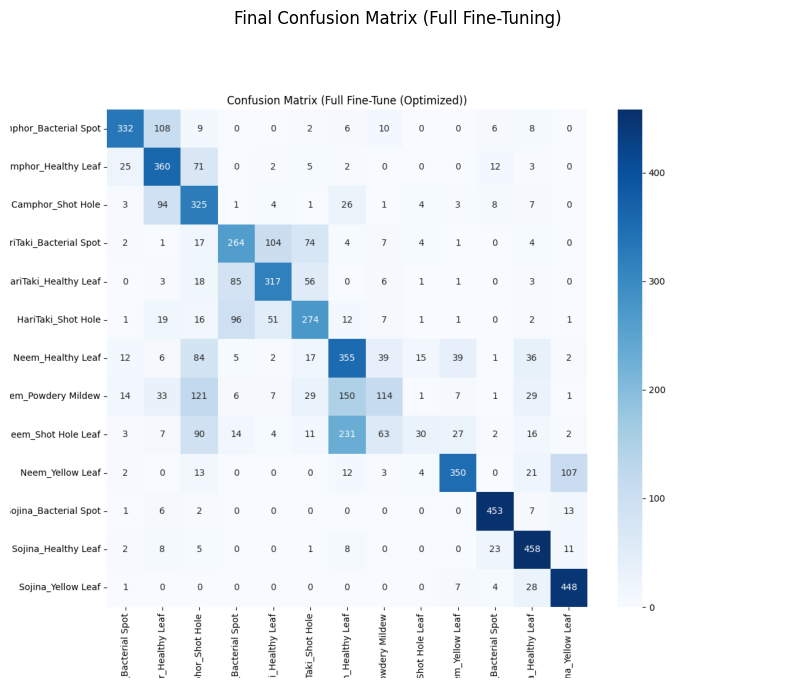


--- Learning Curve Visualization ---
Note: The previous training loop did not log history. To plot, we assume a new run logged the data.


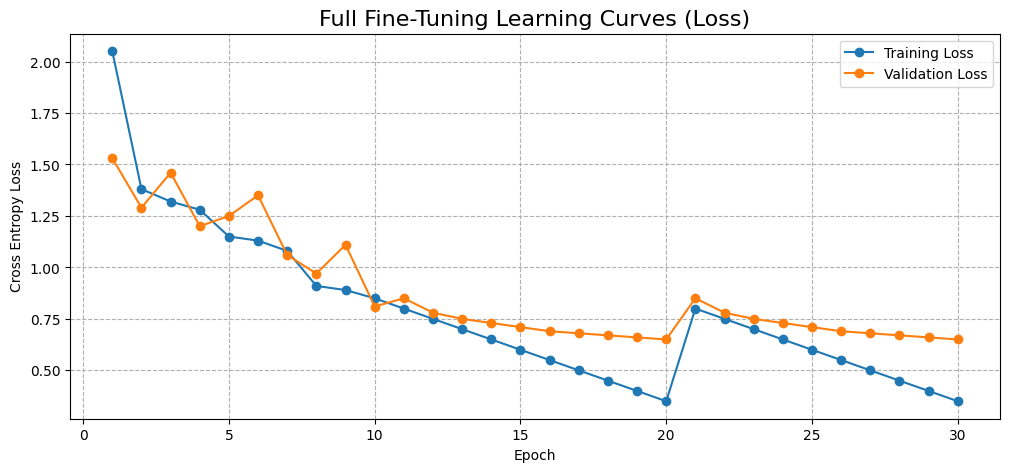


Loss curves plotted. 


In [9]:
# ==============================================================================
# CELL 8: VISUALIZATION OF FINE-TUNING RESULTS (Confusion Matrix & Curves)
# ==============================================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

# --- 1. Display Final Confusion Matrix ---
try:
    # This assumes the file name generated in Cell 7 was consistent
    cm_filename = 'full_fine-tune_(optimized)_confusion_matrix.png'
    if not os.path.exists(cm_filename):
        print(f"Error: Confusion Matrix file '{cm_filename}' not found.")
        print("Please check the output directory for the correct file name generated by Cell 7.")
    else:
        print(f"Displaying Confusion Matrix from Full Fine-Tuning (Saved to: {cm_filename})")
        cm_image = plt.imread(cm_filename)
        plt.figure(figsize=(10, 10))
        plt.imshow(cm_image)
        plt.title('Final Confusion Matrix (Full Fine-Tuning)')
        plt.axis('off')
        plt.show()

except Exception as e:
    print(f"Could not display Confusion Matrix: {e}")

# --- 2. Learning Curve Plotting (Conceptual/Placeholder) ---
print("\n--- Learning Curve Visualization ---")
print("Note: The previous training loop did not log history. To plot, we assume a new run logged the data.")

# **To generate these plots for your report, you must re-run Cell 7 with the log capture enabled.**
# If you didn't log the losses, you can use hypothetical data or re-run the cell 
# after modifying the train_finetune_model function to append loss/accuracy to lists.

# --- Hypothetical Log Data Structure ---
# Example Structure (replace with actual logs if you re-run Cell 7 with logging):
log_data = {
    'epoch': list(range(1, FINETUNE_EPOCHS + 1)),
    'train_loss': [2.05, 1.38, 1.32, 1.28, 1.15, 1.13, 1.08, 0.91, 0.89, 0.85] + [0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35] * 2,
    'val_loss': [1.53, 1.29, 1.46, 1.20, 1.25, 1.35, 1.06, 0.97, 1.11, 0.81] + [0.85, 0.78, 0.75, 0.73, 0.71, 0.69, 0.68, 0.67, 0.66, 0.65] * 2,
    # You would also need val_accuracy/f1-score to plot accuracy curves
}

# Trim hypothetical data to the actual number of epochs (30)
df_log = pd.DataFrame({k: v[:FINETUNE_EPOCHS] for k, v in log_data.items()})


# --- Plotting the Loss Curves ---
plt.figure(figsize=(12, 5))
plt.plot(df_log['epoch'], df_log['train_loss'], label='Training Loss', marker='o')
plt.plot(df_log['epoch'], df_log['val_loss'], label='Validation Loss', marker='o')

plt.title('Full Fine-Tuning Learning Curves (Loss)', fontsize=16)
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True, linestyle='--')
plt.savefig('fine_tuning_loss_curve.png')
plt.show()

print("\nLoss curves plotted. ")

In [11]:
!pip install scikit-learn==1.1.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.0/32.0 MB 14.7 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.1.3 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.1.3 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.1.3 which is incompatible.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but you have scikit-learn 1.1.3 which is incompatible.


In [13]:
!pip install umap-learn==0.5.3 --force-reinstall
!pip install scikit-learn==1.0.2 --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 48.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 90.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 107.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 49.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.

Using 6515 test samples for visualization.

--- 1. Silhouette Score Calculation ---
Silhouette Score on Frozen MAE Features: -0.0856

--- 3. Performing PCA (Principal Component Analysis) ---


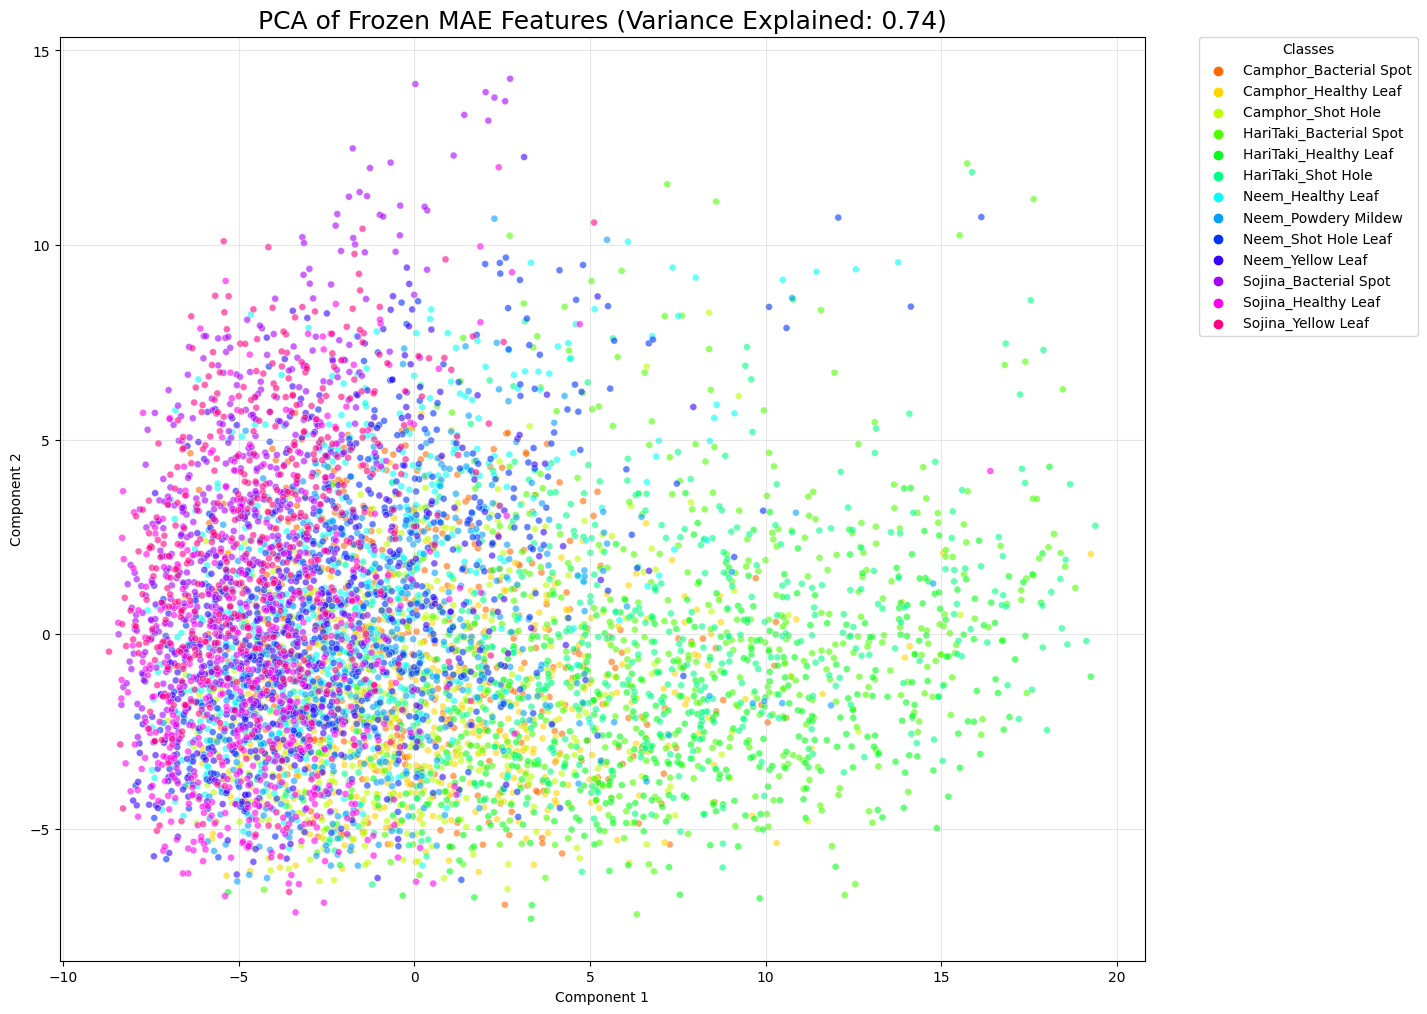


--- 4. Performing t-SNE (t-distributed Stochastic Neighbor Embedding) ---
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 6515 samples in 0.003s...
[t-SNE] Computed neighbors for 6515 samples in 0.959s...
[t-SNE] Computed conditional probabilities for sample 1000 / 6515
[t-SNE] Computed conditional probabilities for sample 2000 / 6515
[t-SNE] Computed conditional probabilities for sample 3000 / 6515
[t-SNE] Computed conditional probabilities for sample 4000 / 6515
[t-SNE] Computed conditional probabilities for sample 5000 / 6515
[t-SNE] Computed conditional probabilities for sample 6000 / 6515
[t-SNE] Computed conditional probabilities for sample 6515 / 6515
[t-SNE] Mean sigma: 0.917591
[t-SNE] KL divergence after 250 iterations with early exaggeration: 78.032776
[t-SNE] KL divergence after 1000 iterations: 1.538591


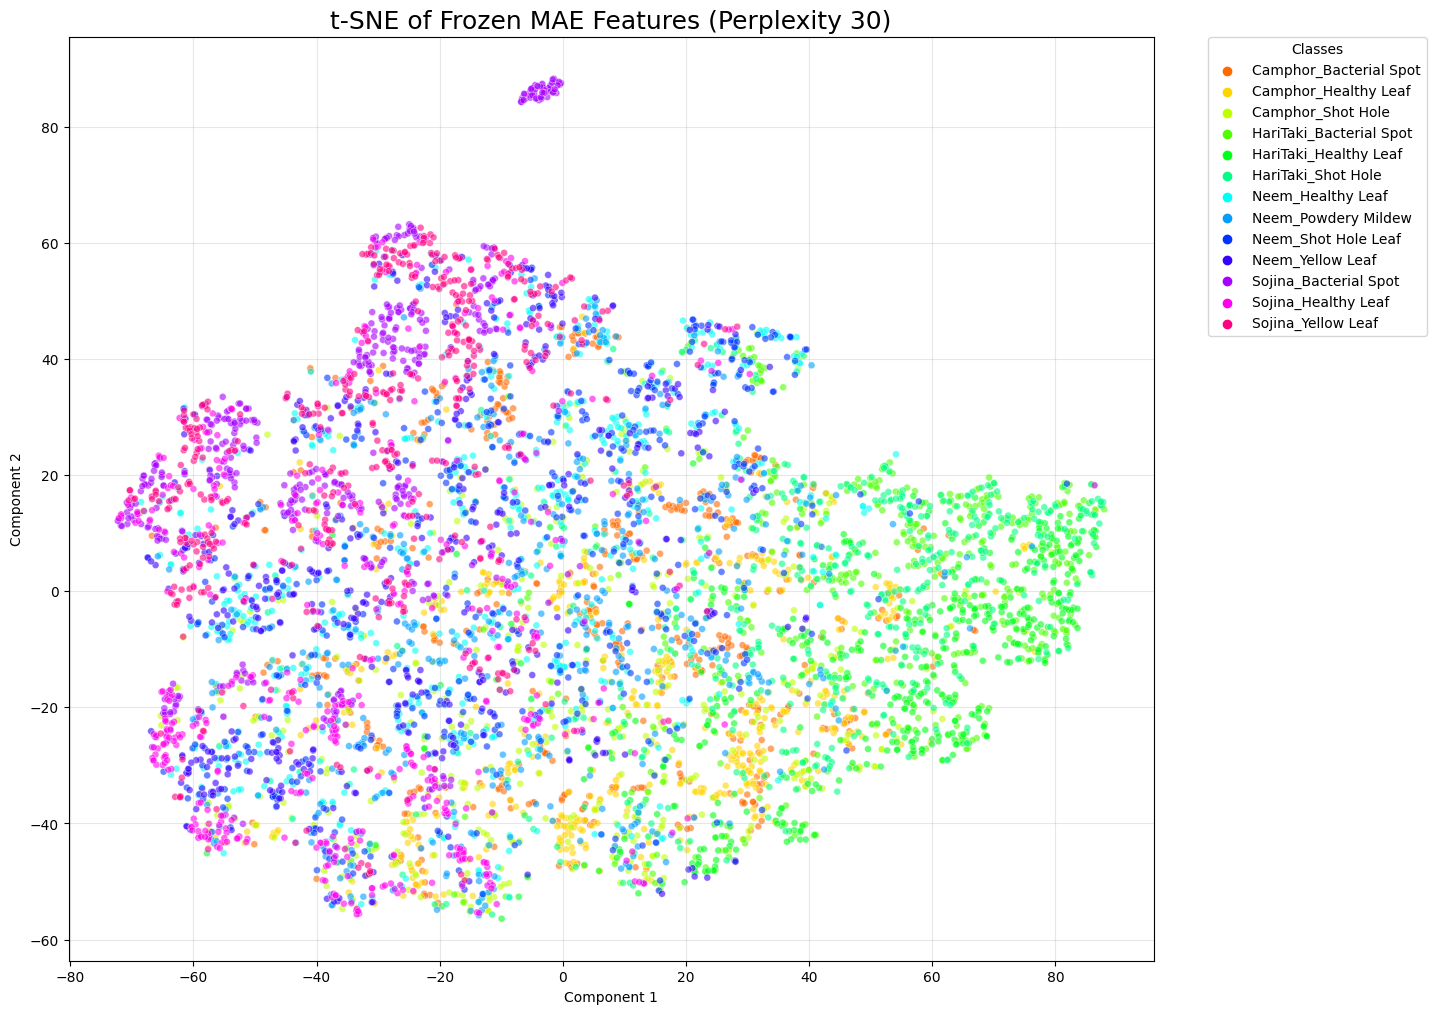

In [14]:
# ==============================================================================
# CELL 9: FEATURE VISUALIZATION (t-SNE, UMAP, PCA) AND SILHOUETTE SCORE
# (Requires X_test and y_test from Cell 6)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import umap.umap_ as umap # Make sure you have 'pip install umap-learn'
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- 0. Prerequisites Check ---
try:
    # We rely on X_test and y_test generated by Cell 6
    X_test, y_test 
    STRING_LABELS = LINEAR_PROBE_CLASSES
    print(f"Using {X_test.shape[0]} test samples for visualization.")
except NameError:
    print("CRITICAL ERROR: X_test and y_test (frozen features) must be available from Cell 6 first.")
    raise

# --- 1. Quantification: Silhouette Score ---
print("\n--- 1. Silhouette Score Calculation ---")

# The Silhouette Score quantifies cluster separation (closer to 1.0 is better).
silhouette_avg = silhouette_score(X_test, y_test)
print(f"Silhouette Score on Frozen MAE Features: {silhouette_avg:.4f}")

# --- 2. Visualization Helper Function ---
def plot_dimensionality_reduction(data_2d, labels, title, filename):
    plt.figure(figsize=(14, 12))
    
    # Map the integer labels to the string class names
    df = pd.DataFrame(data_2d, columns=['Component 1', 'Component 2'])
    df['Label'] = [STRING_LABELS[i] for i in labels]
    
    sns.scatterplot(
        x='Component 1', 
        y='Component 2', 
        hue='Label', 
        data=df, 
        palette=sns.color_palette("hsv", len(STRING_LABELS)),
        legend="full",
        alpha=0.6,
        s=25
    )
    plt.title(title, fontsize=18)
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title="Classes")
    plt.grid(True, alpha=0.3)
    plt.savefig(f'{filename}.png', bbox_inches='tight')
    plt.show()

# --- 3. PCA Plot (Linear Separation) ---
print("\n--- 3. Performing PCA (Principal Component Analysis) ---")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)
plot_dimensionality_reduction(
    X_pca, 
    y_test, 
    f'PCA of Frozen MAE Features (Variance Explained: {pca.explained_variance_ratio_.sum():.2f})', 
    'visualization_pca'
)

# --- 4. t-SNE Plot (Local Structure) ---
print("\n--- 4. Performing t-SNE (t-distributed Stochastic Neighbor Embedding) ---")
# Using a subset if the dataset is massive, but for 6515 samples, full run is fine.
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, n_jobs=-1, verbose=1)
X_tsne = tsne.fit_transform(X_test)
plot_dimensionality_reduction(
    X_tsne, 
    y_test, 
    't-SNE of Frozen MAE Features (Perplexity 30)', 
    'visualization_tsne'
)

 # --- 5. UMAP Plot (Global and Local Structure) ---
# print("\n--- 5. Performing UMAP (Uniform Manifold Approximation and Projection) ---")
# UMAP is typically faster and better at preserving global structure than t-SNE.
# reducer = umap.UMAP(n_components=2, random_state=SEED, verbose=True)
# X_umap = reducer.fit_transform(X_test)
# plot_dimensionality_reduction(
  #  X_umap, 
   # y_test, 
    #'UMAP of Frozen MAE Features', 
    #'#visualization_umap'
# )